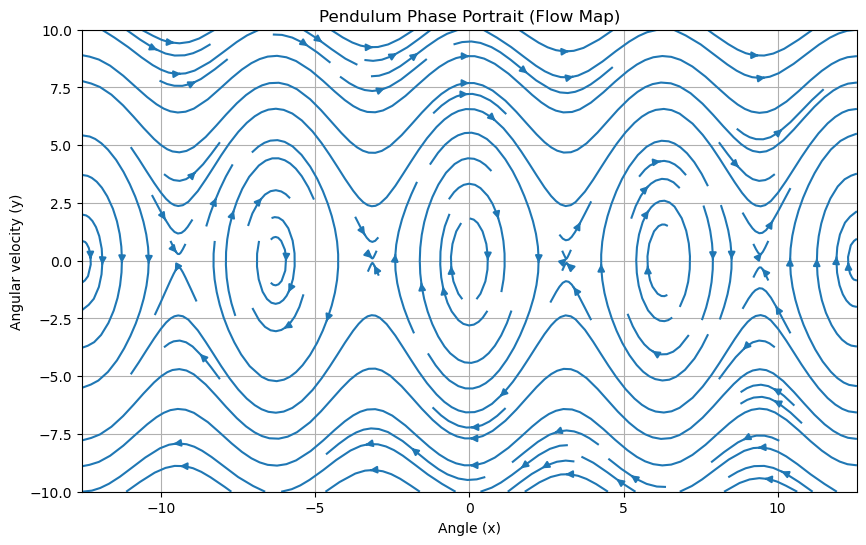

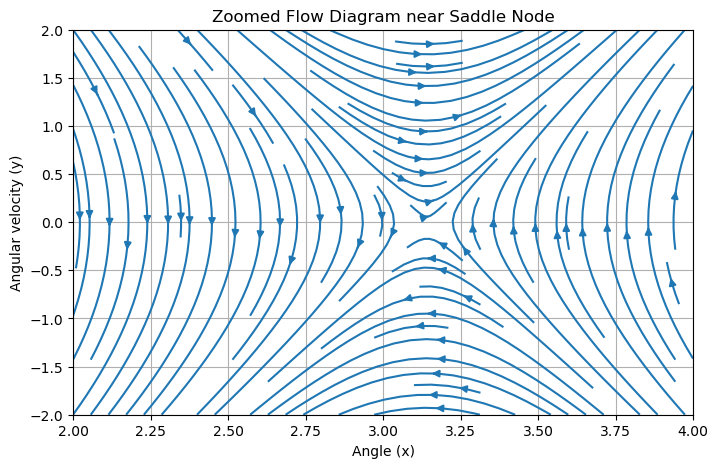

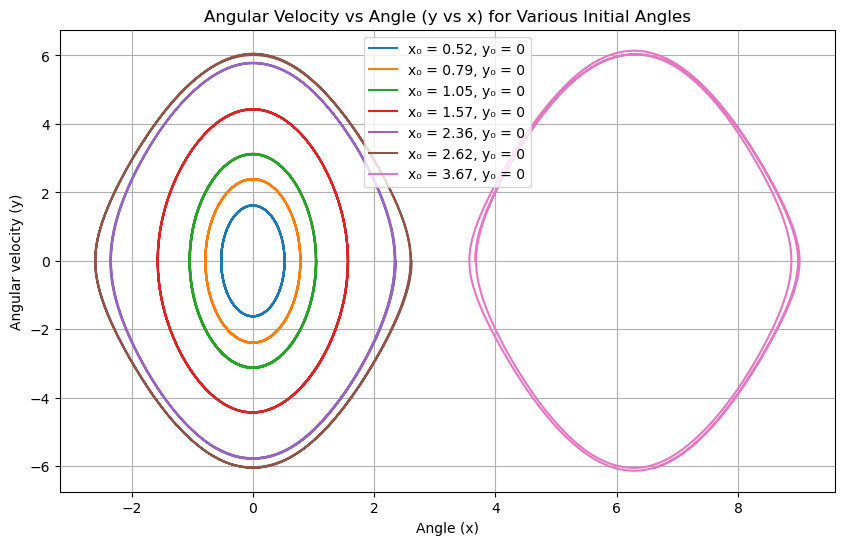

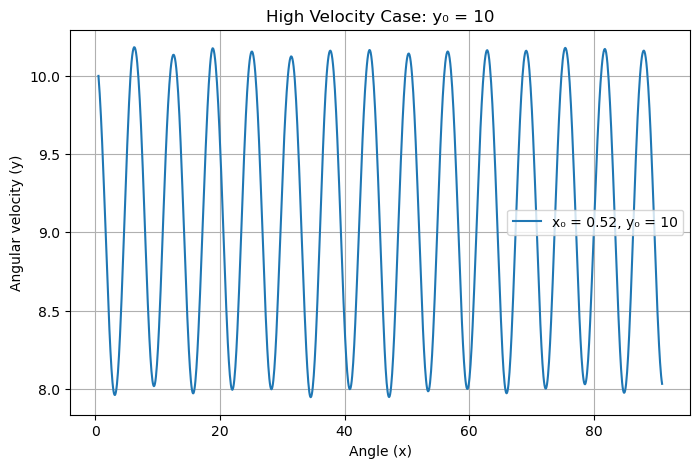

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

g = 9.81
L = 1.0

def pendulum(t, z):
    x, y = z
    dxdt = y
    dydt = -(g/L) * np.sin(x)
    return [dxdt, dydt]

x = np.linspace(-4 * np.pi, 4 * np.pi, 40)
y = np.linspace(-10, 10, 40)
X, Y = np.meshgrid(x, y)
U = Y
V = -(g / L) * np.sin(X)

plt.figure(figsize=(10, 6))
plt.streamplot(X, Y, U, V, density=1.2, arrowsize=1)
plt.title('Pendulum Phase Portrait (Flow Map)')
plt.xlabel('Angle (x)')
plt.ylabel('Angular velocity (y)')
plt.grid()
plt.show()

x_zoom = np.linspace(2, 4, 30)
y_zoom = np.linspace(-2, 2, 30)
Xz, Yz = np.meshgrid(x_zoom, y_zoom)
Uz = Yz
Vz = -(g / L) * np.sin(Xz)

plt.figure(figsize=(8, 5))
plt.streamplot(Xz, Yz, Uz, Vz, density=1.2, arrowsize=1)
plt.title('Zoomed Flow Diagram near Saddle Node')
plt.xlabel('Angle (x)')
plt.ylabel('Angular velocity (y)')
plt.grid()
plt.show()

def simulate_and_plot(theta0, y0):
    t_span = (0, 10)
    t_eval = np.linspace(*t_span, 1000)
    sol = solve_ivp(pendulum, t_span, [theta0, y0], t_eval=t_eval)
    plt.plot(sol.y[0], sol.y[1], label=f"x₀ = {np.round(theta0, 2)}, y₀ = {y0}")

initial_angles = [np.pi/6, np.pi/4, np.pi/3, np.pi/2, 3*np.pi/4, 5*np.pi/6, 7*np.pi/6]

plt.figure(figsize=(10, 6))
for angle in initial_angles:
    simulate_and_plot(angle, 0)
plt.title("Angular Velocity vs Angle (y vs x) for Various Initial Angles")
plt.xlabel("Angle (x)")
plt.ylabel("Angular velocity (y)")
plt.grid()
plt.legend()
plt.show()

# High velocity test
plt.figure(figsize=(8, 5))
simulate_and_plot(np.pi/6, 10)
plt.title("High Velocity Case: y₀ = 10")
plt.xlabel("Angle (x)")
plt.ylabel("Angular velocity (y)")
plt.grid()
plt.legend()
plt.show()
